In [67]:
import argparse
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle

plt.rcParams.update(
    {
        "font.family": "serif",  # use serif/main font for text elements
        "text.usetex": True,  # use inline math for ticks
        "pgf.rcfonts": False,  # don't setup fonts from rc parameters
        "axes.labelsize": 17,  # axis labels
        "legend.fontsize": 12,  # legend
        "xtick.labelsize": 15,  # x tick labels
        "ytick.labelsize": 15,  # y tick labels
    }
)

In [68]:
def read_doscar(filename):
    """Read total DOS from a VASP DOSCAR."""

    with open(filename, "r") as f:
        lines = f.readlines()

    # First 5 lines are header
    header = lines[:5]

    # Sixth line contains:
    # Emax Emin NEDOS Efermi weight
    emax, emin, nedos, efermi, *_ = map(float, lines[5].split())
    nedos = int(nedos)

    dos_lines = lines[6:6 + nedos]

    first = dos_lines[0].split()

    # Standard formats:
    #
    # Non-spin:
    # E DOS IntDOS
    #
    # Spin:
    # E DOS(up) DOS(down) Int(up) Int(down)

    if len(first) == 3:
        spin = False
        energy = np.empty(nedos)
        dos = np.empty(nedos)

        for i, line in enumerate(dos_lines):
            e, d, _ = map(float, line.split())
            energy[i] = e - efermi
            dos[i] = d

        return {
            "spin": spin,
            "energy": energy,
            "dos": dos,
            "efermi": efermi,
        }

    elif len(first) == 5:
        spin = True
        energy = np.empty(nedos)
        dos_up = np.empty(nedos)
        dos_down = np.empty(nedos)

        for i, line in enumerate(dos_lines):
            e, up, down, _, _ = map(float, line.split())
            energy[i] = e - efermi
            dos_up[i] = up
            dos_down[i] = down

        return {
            "spin": spin,
            "energy": energy,
            "dos_up": dos_up,
            "dos_down": dos_down,
            "efermi": efermi,
        }

    else:
        raise RuntimeError("Unrecognized DOSCAR format.")

In [78]:
def plot_dos(datas, energy_range=(-2, 2)):

    fig, ax = plt.subplots(figsize=(6, 4))

    for data in datas:
        if data["spin"]:
            ax.plot(data["energy"], data["dos_up"], label="Spin ↑")
            ax.plot(data["energy"], -data["dos_down"], label="Spin ↓")
        else:
            ax.plot(data["energy"], data["dos"], label="DOS")

    ax.axvline(0.0, color="k", linestyle="--", linewidth=1)
    ax.set_xlabel(r"$E-E_F$ (eV)")
    ax.set_ylabel("Density of States")

    axins = inset_axes(
        ax,
        width="40%",
        height="40%",
        loc="upper left",
        borderpad=1.2,
    )
    for data in datas:
        if data["spin"]:
            axins.plot(data["energy"], data["dos_up"])
            axins.plot(data["energy"], -data["dos_down"])
        else:
            axins.plot(data["energy"], data["dos"])

    axins.axvline(0.0, color="k", linestyle="--", linewidth=1)
    axins.set_xlim(energy_range[0], energy_range[1])

    mask = (data["energy"] >= energy_range[0]) & (data["energy"] <= energy_range[1])
    if data["spin"]:
        y = np.r_[data["dos_up"][mask], -data["dos_down"][mask]]
    else:
        y = data["dos"][mask]

    if len(y) > 0:
        ymin, ymax = float(y.min()), float(y.max())
        axins.set_ylim(ymin, ymax)

        # add an unconnected rectangle on the main axes showing the enlarged region
        rect = Rectangle(
            (-2, ymin),
            width=4,
            height=(ymax - ymin),
            linewidth=1.2,
            edgecolor="gray",
            facecolor="none",
            linestyle="--",
            zorder=0,
        )
        ax.add_patch(rect)

    axins.set_xticks([-2, 0, 2])
    axins.set_yticks([])
    # ax.grid()

    fig.tight_layout()
    plt.show()


/tmp/ipykernel_51130/3056415194.py:60: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


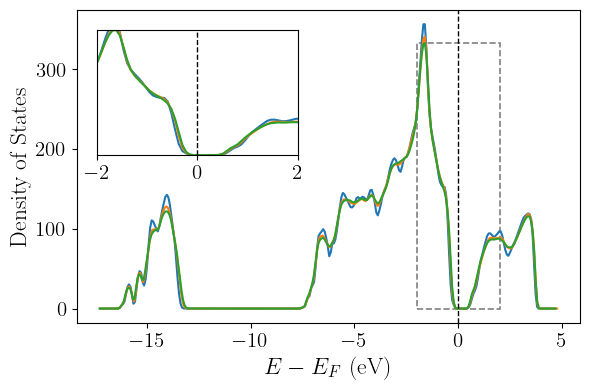

In [84]:
from pathlib import Path

def parse_simulation(sim_dir):
    dos_datas = []

    for config_dir in Path(sim_dir / "2-DFT").glob(
        "config_*"
    ):
        data = read_doscar(config_dir / "DOSCAR")
        dos_datas.append(data)

    # dos_datas contains the DOS data for all configurations.
    # Calculate the mean DOS across all configurations for each energy point.
    mean_dos = np.mean([np.interp(dos_datas[0]["energy"], data["energy"], data["dos"]) for data in dos_datas], axis=0)
    # and the standard deviation
    std_dos = np.std([np.interp(dos_datas[0]["energy"], data["energy"], data["dos"]) for data in dos_datas], axis=0)

    return {
        "energy": dos_datas[0]["energy"],
        "dos": mean_dos,
        "std_dos": std_dos,
        "spin": dos_datas[0]["spin"],
    }    

data_300 = parse_simulation(Path("cluster_results/flow-otter-test/temperature_300.0"))
data_520 = parse_simulation(Path("cluster_results/flow-otter-test/temperature_520.0"))
data_650 = parse_simulation(Path("cluster_results/flow-otter-test/temperature_650.0"))

plot_dos([data_300, data_520, data_650], energy_range=(-2, 2))